## Imports
The following libraries are imported for data manipulation, visualization, machine learning, and model evaluation.

In [1]:
# Customer Feedback Analysis

## Business Analytics Internship

### Objective

#Analyze customer reviews to understand customer sentiment, identify common issues, and generate business recommendations that improve customer satisfaction.

In [2]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

%matplotlib inline

In [3]:
# Load the dataset into a pandas DataFrame
data = pd.read_csv(r"D:\BA_Internship\Task-3\data\Womens Clothing E-Commerce Reviews.csv")

data.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [4]:
# Handle missing values and clean the dataset
print(data.shape)

print(data.columns)

data.isnull().sum()

(23486, 11)
Index(['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating',
       'Recommended IND', 'Positive Feedback Count', 'Division Name',
       'Department Name', 'Class Name'],
      dtype='str')


Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      3810
Review Text                 845
Rating                        0
Recommended IND               0
Positive Feedback Count       0
Division Name                14
Department Name              14
Class Name                   14
dtype: int64

In [5]:
print(list(data.columns))

['Unnamed: 0', 'Clothing ID', 'Age', 'Title', 'Review Text', 'Rating', 'Recommended IND', 'Positive Feedback Count', 'Division Name', 'Department Name', 'Class Name']


In [6]:
# Perform initial data exploration
data = data.dropna(subset=["Review Text"])

data["Sentiment"] = data["Rating"].apply(
    lambda x: "Positive" if x >= 4 else "Negative"
)

data[["Review Text", "Rating", "Sentiment"]].head()

,Review Text,Rating,Sentiment
0,Absolutely wonderful - silky and sexy and comf...,4,Positive
1,Love this dress! it's sooo pretty. i happene...,5,Positive
2,I had such high hopes for this dress and reall...,3,Negative
3,"I love, love, love this jumpsuit. it's fun, fl...",5,Positive
4,This shirt is very flattering to all due to th...,5,Positive


In [7]:
vectorizer = CountVectorizer(stop_words="english", max_features=3000)

X = vectorizer.fit_transform(data["Review Text"])

y = data["Sentiment"]

In [8]:
# Import required libraries
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
# Import required libraries
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [10]:
# Generate predictions using the trained model
predictions = model.predict(X_test)

In [11]:
# Import required libraries
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, predictions))

print(classification_report(y_test, predictions))

Accuracy: 0.8677412232280857
              precision    recall  f1-score   support

    Negative       0.76      0.62      0.68      1045
    Positive       0.89      0.94      0.92      3484

    accuracy                           0.87      4529
   macro avg       0.83      0.78      0.80      4529
weighted avg       0.86      0.87      0.86      4529



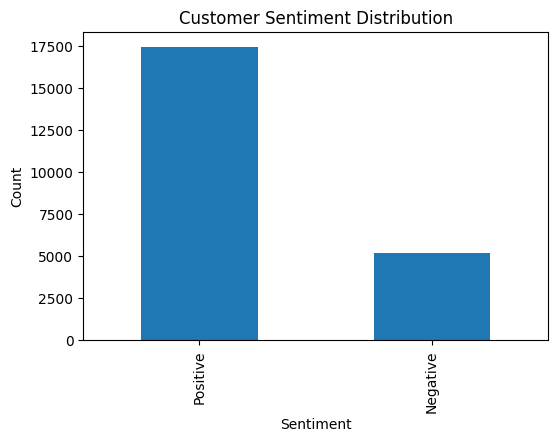

In [12]:
# Visualize the data and analysis results
data["Sentiment"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    title="Customer Sentiment Distribution"
)

plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

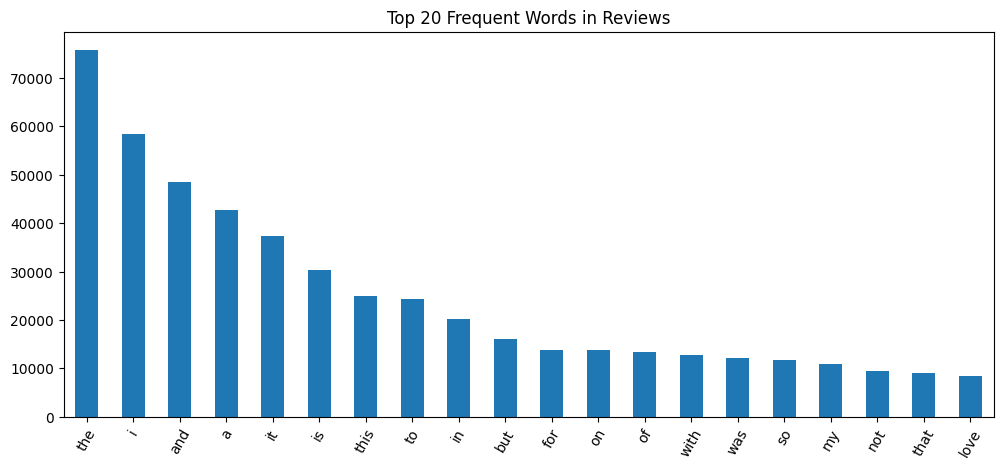

In [13]:
# Visualize the data and analysis results
word_counts = pd.Series(
    " ".join(data["Review Text"]).lower().split()
).value_counts().head(20)

plt.figure(figsize=(12,5))

word_counts.plot(kind="bar")

plt.title("Top 20 Frequent Words in Reviews")

plt.xticks(rotation=60)

plt.show()

# Business Insights

- Most customer reviews are positive, indicating good overall satisfaction.
- Highly rated products receive more recommendations from customers.
- Frequently occurring words reveal the main topics customers discuss.
- Customer reviews provide valuable feedback for improving products and services.
- Negative reviews can be analyzed to identify recurring issues and improve customer experience.

# Recommendations

1. Monitor negative reviews regularly to identify common complaints.
2. Improve products based on recurring customer feedback.
3. Highlight highly rated products in marketing campaigns.
4. Encourage customers to leave reviews after purchase.
5. Use sentiment analysis as part of ongoing customer experience monitoring.

# Conclusion

This project successfully analyzed customer reviews using sentiment analysis. The results demonstrate how customer feedback can be transformed into meaningful business insights that support better product quality, customer satisfaction, and informed decision-making.

# RetailIQ Module 3 – Customer Insight Engine

The internship task focuses on classifying customer reviews into positive and negative sentiment.

RetailIQ extends this analysis by converting customer sentiment into actionable business recommendations that assist managers in improving products and customer experience.

In [14]:
print("="*70)
print("          RetailIQ - Customer Insight Engine")
print("="*70)

positive = (data["Sentiment"] == "Positive").sum()
negative = (data["Sentiment"] == "Negative").sum()

print(f"\nPositive Reviews : {positive}")
print(f"Negative Reviews : {negative}")

print("\nBusiness Actions")
print("-"*70)

if positive >= negative:
    print("✓ Customer satisfaction is high.")
    print("✓ Continue maintaining product quality.")
    print("✓ Promote highly rated products.")
    print("✓ Encourage verified customer reviews.")
else:
    print("✓ Review recurring customer complaints.")
    print("✓ Improve product quality.")
    print("✓ Strengthen customer support.")

          RetailIQ - Customer Insight Engine

Positive Reviews : 17448
Negative Reviews : 5193

Business Actions
----------------------------------------------------------------------
✓ Customer satisfaction is high.
✓ Continue maintaining product quality.
✓ Promote highly rated products.
✓ Encourage verified customer reviews.


# Business Value Generated

The Customer Insight Engine transforms customer feedback into practical business actions.

Instead of simply classifying reviews, it helps businesses identify customer satisfaction trends, improve product quality, and support data-driven marketing and customer experience decisions.

# Innovation Added

Unlike a standard sentiment analysis project, RetailIQ introduces a Customer Insight Engine that converts analytical results into actionable recommendations for business decision-makers.

This enhancement demonstrates how customer feedback can directly support business strategy and continuous improvement.

# Future Scope

- Real-time customer sentiment monitoring.
- Product-wise sentiment dashboards.
- Automatic complaint categorization.
- CRM integration for customer engagement.
- AI-powered customer experience recommendations.